In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, "../../../../Modules/")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [3]:
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv'

dataset = read_data(path)
dataset.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,22.215876,40.552658,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,4.435606,6.168909,2.702302,-0.015091,12.092545,6.794681,NaN,NaN,NaN,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,81.134845,15.306163,25.795942,35.973005,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,NaN,NaN,1043.454545,0,10083.753176,2604.220647,14,151.983874,145.068848,169.450815,0.0,3.764491,31,83,36,84.0,30,83,12,12,1,6,7,2,0
1,23.139532,40.695359,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,4.816764,7.923406,1.710122,-2.877717,13.860079,6.961915,NaN,NaN,NaN,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,42.311748,7.807795,13.338001,19.783772,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,NaN,NaN,740.125984,0,4609.324076,1275.656385,3,156.077628,106.345725,180.535489,0.0,3.928386,31,97,36,97.0,30,97,12,12,1,6,7,2,0
2,22.758634,41.016242,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,3.765541,7.190461,0.340620,-4.895934,12.183407,5.888491,NaN,NaN,NaN,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,53.173589,9.279576,14.213017,18.993597,5963.0,24603.0,9769.0,40335.0,5680.0,23436.0,11889.0,41005.0,1124.52,NaN,NaN,631.285714,0,14539.491549,1973.650189,5,180.265199,154.698694,180.171598,0.0,10.143914,31,98,36,96.0,30,98,12,12,3,5,8,2,0
3,22.109199,40.888821,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,3.694941,6.414831,0.975051,-3.823409,11.261136,6.293877,NaN,NaN,NaN,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,81.491186,14.713423,22.905129,32.657020,11159.0,44537.0,14694.0,70390.0,11052.0,43212.0,17690.0,71954.0,1938.34,NaN,NaN,869.318182,0,20467.087760,2556.132830,4,227.370939,344.084297,191.478748,0.0,1.165700,31,86,30,86.0,30,86,10,10,1,6,6,2,0
4,22.441443,40.269748,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,6.091283,8.354315,3.828251,1.550444,15.961111,8.601499,NaN,NaN,NaN,11.918324,NaN,NaN,NaN,5.2846

In [4]:
dataset.shape

(1092, 96)

In [5]:
dataset = encode_cyclical(dataset, 'month', 12)
dataset = convert_multiple_cases(dataset, target_col='cases')

In [6]:
## Simple output binarization

# dataset.drop_duplicates(keep='first', inplace=True, ignore_index=True)
# dataset

In [7]:
dataset.cases.unique()

array([0, 1], dtype=int64)

In [8]:
dataset.shape

(1817, 98)

In [9]:
dataset.rename(columns={"cases": "case"}, inplace=True)

In [10]:
dataset.columns

Index(['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME',
       'NUTS3_ID', 'NUTS3_NAME', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lst', 'lst_day',
       'lst_night', 'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean',
       'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'monthly_acc_prec',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64',
       'F_Y_GE65', 'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 

In [11]:
print(f'Number of NUTS3 Units in {NUTS2}: {len(dataset.NUTS3_NAME.unique())}')

Number of NUTS3 Units in CMacedonia: 7


In [12]:
dsc = dataframe_describe(dataset, target_column = 'case')
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,64,250,314,17.28%
1,2011,72,31,103,5.67%
2,2012,74,20,94,5.17%
3,2013,75,21,96,5.28%
4,2014,84,0,84,4.62%
5,2015,84,0,84,4.62%
6,2016,84,0,84,4.62%
7,2017,84,0,84,4.62%
8,2018,65,117,182,10.02%
9,2019,67,53,120,6.60%


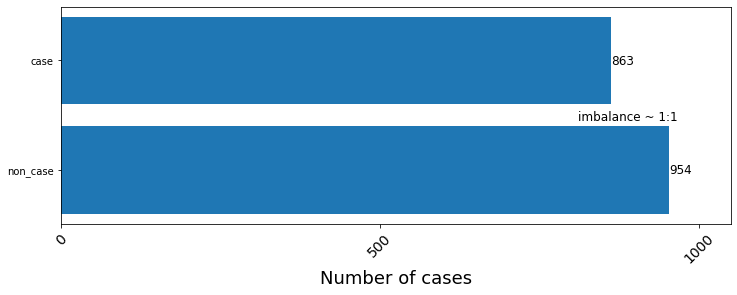

In [13]:
plot_imbalance(dataset, target_column='case')

In [14]:
majority_class = 0
near_u = 0
smote = 0
scaler = 'minmax'
weight_multiplier = 1

years_to_remove = [2014,2015,2016,2017]
features_to_remove = ['x', 'y','month', 'year','lc_prop1_assessment','lc_prop2_assessment', 
                      'lc_prop3_assessment', 'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5',
                      'lw', 'qc']

In [15]:
model_ft_importances = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'] 
                                                               + features_to_remove).columns

print(feature_names)

Index(['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lst', 'lst_day', 'lst_night', 'monthly_lst_min',
       'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
       'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
       'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'M_Y_LT15', 'M_Y15-64',
       'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'mosq_pred', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_m

In [16]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, 'case', scaler, majority_class, features_to_remove)

    w = calculate_scale_pos_weight(y_train, weight_multiplier)

    model = xgb.XGBClassifier(verbosity=0, seed = 0, device = 'cuda', max_depth = 3, scale_pos_weight = w, objective='binary:logistic', eval_metric = 'logloss')

    trained_model, model_shap = train_tree_model(model, X_train, y_train, explain=True)

    train, test, ft = predict_xgb_model(trained_model, X_train, y_train, X_test, y_test, data_test, day_col = None, spatial_col = 'NUTS3_NAME')

    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_ft_importances.append(ft)
    model_shaps.append(model_shap)
    
    print(f"Year: {test['year'].iloc[0]} || w:{round(w,3)} || ##")

shap_values= np.concatenate(model_shaps, axis=0)
stacked_ft = np.stack(model_ft_importances, axis=0)
ft_values = np.mean(stacked_ft, axis=0)

Year: 2010 || w:0.904 || ##
Year: 2011 || w:0.656 || ##
Year: 2012 || w:0.645 || ##
Year: 2013 || w:0.645 || ##
Year: 2014 || w:0.716 || ##
Year: 2015 || w:0.716 || ##
Year: 2016 || w:0.716 || ##
Year: 2017 || w:0.716 || ##
Year: 2018 || w:0.741 || ##
Year: 2019 || w:0.68 || ##
Year: 2020 || w:0.718 || ##
Year: 2021 || w:0.668 || ##
Year: 2022 || w:0.878 || ##


In [17]:
feature_names

Index(['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lst', 'lst_day', 'lst_night', 'monthly_lst_min',
       'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
       'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
       'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'M_Y_LT15', 'M_Y15-64',
       'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'mosq_pred', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_m

In [18]:
len(feature_names)

79

In [19]:
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9',
               'bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']

weather = ['lst', 'lst_day', 'lst_night',
           'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean',
           'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
           'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
           'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
           'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
           'acc_rainfall_2week', 'acc_rainfall_jan']

indicies = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
            'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
            'ndbi_std',]

demographic = ['M_TOTAL','M_Y_LT_15','M_Y15-64','M_Y_GE65','F_TOTAL','F_Y_LT_15','F_Y15-64','F_Y_GE65']

vectors = ['mosq_pred']

trade = ['L_TOTAL',	'UNL_TOTAL']

economic = ['MIO_EUR']

geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
                    'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
                    'flow_accu_200m', 'lc_prop1', 'lc_prop1_assessment', 'lc_prop2',
                    'lc_prop2_assessment', 'lc_prop3', 'lc_prop3_assessment', 'lc_type1',
                    'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw', 'qc',]

spatiotemporal = ['month_sin', 'month_cos', 'x', 'y','month', 'year',]

In [20]:
len(indicies + weather + demographic + bioclimatic + spatiotemporal + vectors + trade + economic + geomorphological)

92

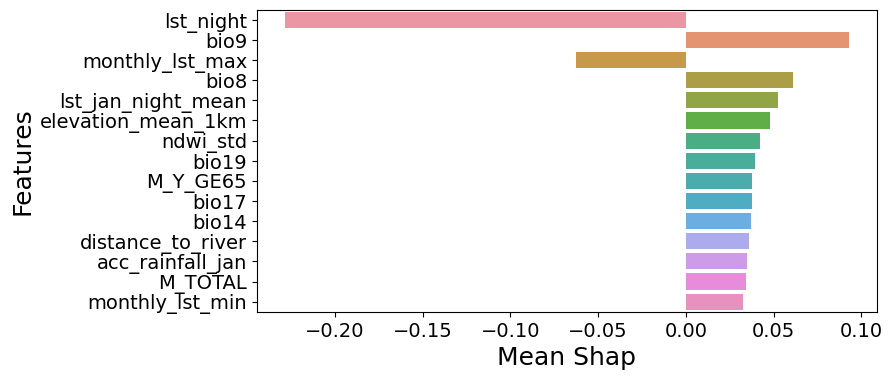

In [21]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

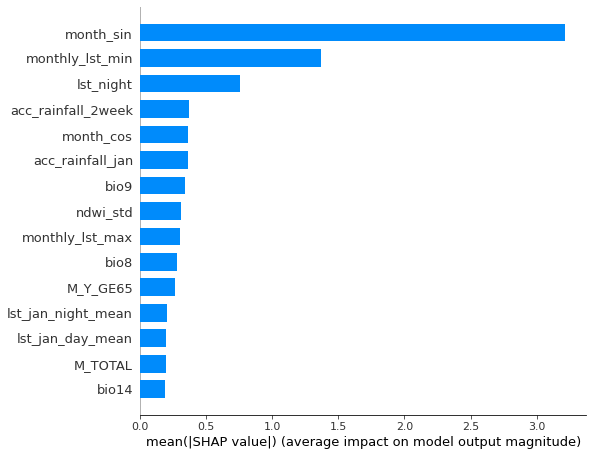

In [22]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

,features,weights
1,weather,0.025486
4,spatiotemporal,0.021562
3,bioclimatic,0.021026
2,demographic,0.015860
0,rs_indicies,0.012382
5,vectors,0.012362
8,geomorphological,0.009518
6,trade,0.002469
7,economic,0.001901


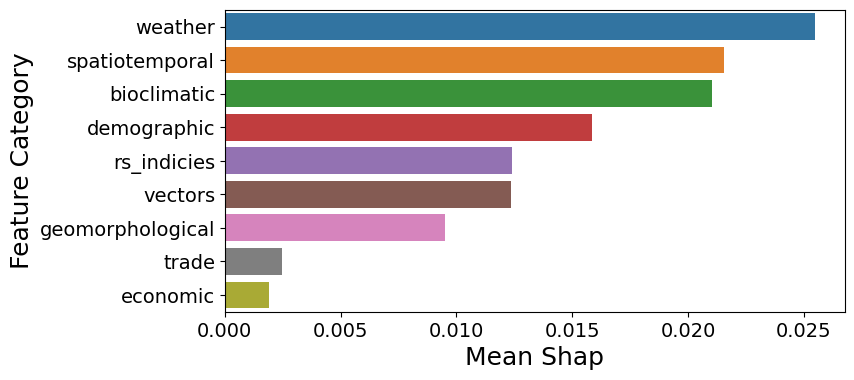

In [23]:
df_indicies = shaps.loc[shaps['features'].isin(indicies)].drop(columns=['weights'])
df_weather = shaps.loc[shaps['features'].isin(weather)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_spatiotemporal = shaps.loc[shaps['features'].isin(spatiotemporal)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])

categories = {'Category': ['rs_indicies', 'weather', 
                           'demographic', 'bioclimatic', 
                           'spatiotemporal', 'vectors',
                           'trade', 'economic', 'geomorphological'], 
              'Mean_Shap': [df_indicies.weights_abs.mean(),df_weather.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_bioclimatic.weights_abs.mean(),
                            df_spatiotemporal.weights_abs.mean(),df_vectors.weights_abs.mean(),
                            df_trade.weights_abs.mean(),df_economic.weights_abs.mean(),
                            df_geomorphological.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,9)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

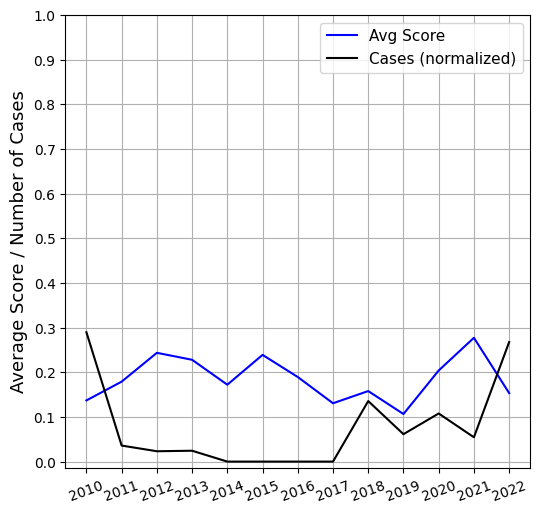

In [24]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']), x_label='', y_label='Average Score / Number of Cases', label_size = 13, tick_size=10, legend_size=11, figure_size = (6, 6) )

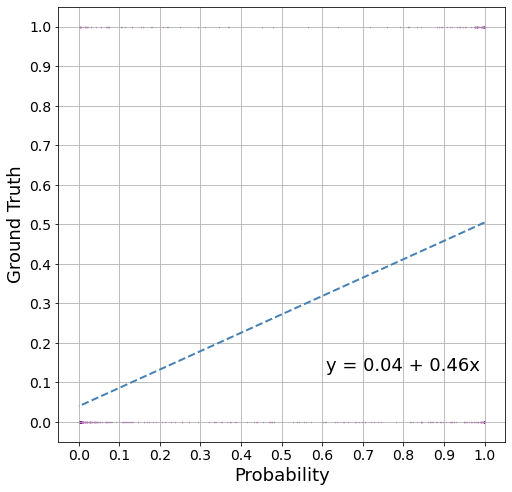

(0.03990953789741629, 0.4648243023555973)

In [25]:
plot_probability_curve(results_test)

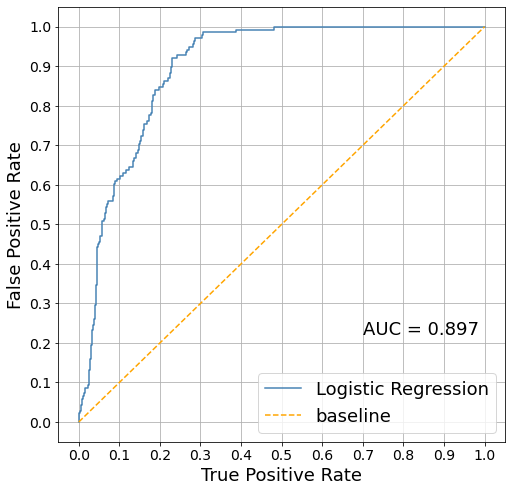

(0.2296, 0.9203, 0.015, 0.842)

In [26]:
plot_roc_curve(results_test, plot_gmean=False)

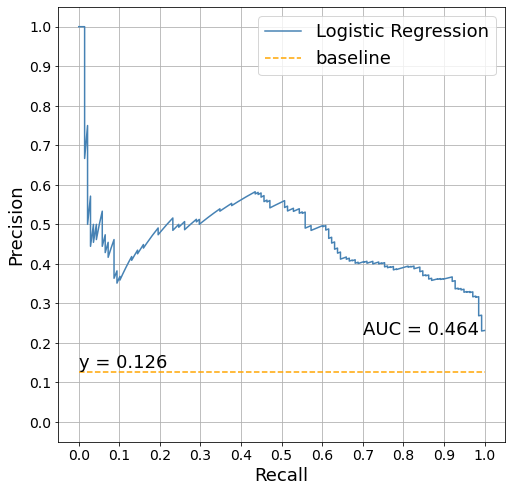

(0.9203, 0.37, 0.02, 0.7071)

In [27]:
plot_pr_curve(results_test, plot_fbeta = False)

In [28]:
results_test

,NUTS3_NAME,month,year,case,score
0,ημαθια,9,2020,1,0.999955
1,θεσσαλονικη,9,2020,1,0.999953
2,θεσσαλονικη,8,2015,0,0.999935
3,πελλα,9,2020,1,0.999911
4,ημαθια,8,2012,0,0.999902
...,...,...,...,...,...
1087,πιερια,2,2017,0,0.000003
1088,ημαθια,1,2021,0,0.000003
1089,σερρες,1,2019,0,0.000003
1090,σερρες,2,2019,0,0.000002


In [29]:
results_test.head(30)

,NUTS3_NAME,month,year,case,score
0,ημαθια,9,2020,1,0.999955
1,θεσσαλονικη,9,2020,1,0.999953
2,θεσσαλονικη,8,2015,0,0.999935
3,πελλα,9,2020,1,0.999911
4,ημαθια,8,2012,0,0.999902
5,χαλκιδικη,8,2015,0,0.999862
6,σερρες,8,2021,1,0.999778
7,ημαθια,8,2015,0,0.999757
8,θεσσαλονικη,9,2015,0,0.999753
9,πελλα,8,2012,1,0.999686
